## 1.计算A股流通市值和A股总市值
## Calculate the free-float market capitalization and total market capitalization of A-shares

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

capital_dt = pd.read_parquet('data/capital.parquet')
capital_dt=capital_dt.sort_values(by=['stock_code', 'change_date'], ascending=[True, True])
capital_dt.rename(columns={'change_date': 'trade_date'}, inplace=True)
price_dt = pd.read_parquet('data/eod_prices.parquet')
price_dt=price_dt.sort_values(by=['stock_code', 'trade_date'], ascending=[True, True])
mv_factor_dt=pd.merge(price_dt, capital_dt, on=['stock_code', 'trade_date'], how='left')
mv_factor_dt.fillna(method='ffill', inplace=True)
mv_factor_dt.head()


,stock_code,trade_date,close_price,adjusted_close,adj_factor,volume,turnover,total_shares,float_shares,total_a_shares,float_a_shares
0,000001.SZ,20130104,15.99,355.0546,22.204789,443851.37,717567.5466,NaN,NaN,NaN,NaN
1,000001.SZ,20130107,16.30,361.9381,22.204789,357169.25,578450.4876,NaN,NaN,NaN,NaN
2,000001.SZ,20130108,16.00,355.2766,22.204789,312479.12,501360.0937,NaN,NaN,NaN,NaN
3,000001.SZ,20130109,15.86,352.1680,22.204789,251329.15,399696.1831,NaN,NaN,NaN,NaN
4,000001.SZ,20130110,15.87,352.3900,22.204789,240030.27,383347.7326,NaN,NaN,NaN,NaN


In [3]:
mv_factor_dt['float_a_shares_mv']=mv_factor_dt['float_a_shares']*mv_factor_dt['close_price']
mv_factor_dt['total_a_shares_mv']=mv_factor_dt['total_a_shares']*mv_factor_dt['close_price']
mv_factor_dt.tail()

,stock_code,trade_date,close_price,adjusted_close,adj_factor,volume,turnover,total_shares,float_shares,total_a_shares,float_a_shares,float_a_shares_mv,total_a_shares_mv
12065642,920992.BJ,20251124,17.93,18.5230,1.033073,14658.45,26244.446,9674.163836,4740.627222,9673.609463,4739.70589,84982.926613,173447.817676
12065643,920992.BJ,20251125,18.05,18.6470,1.033073,10126.13,18280.210,9674.163836,4740.627222,9673.609463,4739.70589,85551.691320,174608.650812
12065644,920992.BJ,20251126,17.80,18.3887,1.033073,10567.74,19017.103,9674.163836,4740.627222,9673.609463,4739.70589,84366.764847,172190.248446
12065645,920992.BJ,20251127,17.65,18.2337,1.033073,7207.73,12856.675,9674.163836,4740.627222,9673.609463,4739.70589,83655.808964,170739.207026
12065646,920992.BJ,20251128,17.58,18.1614,1.033073,7501.27,13195.610,9674.163836,4740.627222,9673.609463,4739.70589,83324.029551,170062.054364


## 2.插入行业分类信息,计算市值因子
## Insert industry classification information and calculate market capitalization factors
*A股流通市值 = close_price * float_a_shares*

*A股总市值 = close_price * total_a_shares*

(PS:理论上小市值策略应该只看A股流通市值，直接跟资金盘相关)
(PS: The small-cap strategy should only consider the free-float market capitalization of A-shares, which is directly related to the money market.)

*市值因子1 = -Ln(A股流通市值) 全局标准化*
(Market capitalization factor 1: Global standardization of the free-float market capitalization of A-shares)

*市值因子2 = -Ln(A股总市值) 全局标准化*
(Market capitalization factor 2: Global standardization of the total market capitalization of A-shares)


In [4]:
cat_df=pd.read_parquet('data/ref_data/Stock_Industry_Year.parquet')
mv_factor_dt['industry_name'] = mv_factor_dt.assign(year=pd.to_datetime(mv_factor_dt['trade_date'].astype(str)).dt.year).merge(cat_df[['stock_code', 'year', 'industry_name']], on=['stock_code', 'year'], how='left')['industry_name']

In [5]:
import numpy as np
mv_factor_dt.dropna(inplace=True)
mv_factor_dt['mv_flt']=-np.log(mv_factor_dt['float_a_shares_mv'])
mv_factor_dt['mv_tot']=-np.log(mv_factor_dt['total_a_shares_mv'])
mv_factor_dt.head()

,stock_code,trade_date,close_price,adjusted_close,adj_factor,volume,turnover,total_shares,float_shares,total_a_shares,float_a_shares,float_a_shares_mv,total_a_shares_mv,industry_name,mv_flt,mv_tot
102,000001.SZ,20130614,19.06,423.2233,22.204789,328553.36,6.251254e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.918767e+06,9.765651e+06,银行,-15.593639,-16.094382
103,000001.SZ,20130617,19.24,427.2201,22.204789,309210.22,5.961902e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.974663e+06,9.857876e+06,银行,-15.603038,-16.103781
104,000001.SZ,20130618,19.73,438.1005,22.204789,389599.38,7.701559e+05,512437.850182,310502.606910,512363.631057,310533.405247,6.126824e+06,1.010893e+07,银行,-15.628187,-16.128930
105,000001.SZ,20130619,19.24,427.2201,22.204789,369977.53,7.140700e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.974663e+06,9.857876e+06,银行,-15.603038,-16.103781
106,000001.SZ,20130620,11.18,400.6981,35.840616,903066.54,1.029738e+06,819808.237690,496861.283537,819958.402672,496892.496412,5.555258e+06,9.167135e+06,银行,-15.530255,-16.031135


In [6]:
# 按交易日期分组，对当天全股票池的mv_flt列做Z-score标准化（(值-均值)/标准差）
mv_factor_dt['mv_flt_std'] = mv_factor_dt.groupby('trade_date')['mv_flt'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0  # 避免标准差为0时除以0报错
)

mv_factor_dt['mv_tot_std'] = mv_factor_dt.groupby('trade_date')['mv_tot'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0  # 避免标准差为0时除以0报错
)
mv_factor_dt.head()


,stock_code,trade_date,close_price,adjusted_close,adj_factor,volume,turnover,total_shares,float_shares,total_a_shares,float_a_shares,float_a_shares_mv,total_a_shares_mv,industry_name,mv_flt,mv_tot,mv_flt_std,mv_tot_std
102,000001.SZ,20130614,19.06,423.2233,22.204789,328553.36,6.251254e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.918767e+06,9.765651e+06,银行,-15.593639,-16.094382,-1.744443,-2.218485
103,000001.SZ,20130617,19.24,427.2201,22.204789,309210.22,5.961902e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.974663e+06,9.857876e+06,银行,-15.603038,-16.103781,-1.750973,-2.226354
104,000001.SZ,20130618,19.73,438.1005,22.204789,389599.38,7.701559e+05,512437.850182,310502.606910,512363.631057,310533.405247,6.126824e+06,1.010893e+07,银行,-15.628187,-16.128930,-1.774256,-2.250456
105,000001.SZ,20130619,19.24,427.2201,22.204789,369977.53,7.140700e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.974663e+06,9.857876e+06,银行,-15.603038,-16.103781,-1.757097,-2.230350
106,000001.SZ,20130620,11.18,400.6981,35.840616,903066.54,1.029738e+06,819808.237690,496861.283537,819958.402672,496892.496412,5.555258e+06,9.167135e+06,银行,-15.530255,-16.031135,-1.726456,-2.194585


In [9]:
mv_factor_dt.tail()

,stock_code,trade_date,close_price,adjusted_close,adj_factor,volume,turnover,total_shares,float_shares,total_a_shares,float_a_shares,float_a_shares_mv,total_a_shares_mv,industry_name,mv_flt,mv_tot,mv_flt_std,mv_tot_std
12065642,920992.BJ,20251124,17.93,18.5230,1.033073,14658.45,26244.446,9674.163836,4740.627222,9673.609463,4739.70589,84982.926613,173447.817676,医药生物,-11.350206,-12.063632,1.797748,1.432967
12065643,920992.BJ,20251125,18.05,18.6470,1.033073,10126.13,18280.210,9674.163836,4740.627222,9673.609463,4739.70589,85551.691320,174608.650812,医药生物,-11.356876,-12.070302,1.805374,1.440739
12065644,920992.BJ,20251126,17.80,18.3887,1.033073,10567.74,19017.103,9674.163836,4740.627222,9673.609463,4739.70589,84366.764847,172190.248446,医药生物,-11.342929,-12.056355,1.809709,1.446056
12065645,920992.BJ,20251127,17.65,18.2337,1.033073,7207.73,12856.675,9674.163836,4740.627222,9673.609463,4739.70589,83655.808964,170739.207026,医药生物,-11.334466,-12.047893,1.821782,1.458540
12065646,920992.BJ,20251128,17.58,18.1614,1.033073,7501.27,13195.610,9674.163836,4740.627222,9673.609463,4739.70589,83324.029551,170062.054364,医药生物,-11.330492,-12.043919,1.837061,1.474868


## 3.单因子(A股流通市值因子)与复合因子(市值因子简单平均赋分)

In [7]:
#简单复合
mv_factor_dt['mv_comp']=0.5*mv_factor_dt['mv_flt_std']+0.5*mv_factor_dt['mv_tot_std']
mv_factor_dt.head()

,stock_code,trade_date,close_price,adjusted_close,adj_factor,volume,turnover,total_shares,float_shares,total_a_shares,float_a_shares,float_a_shares_mv,total_a_shares_mv,industry_name,mv_flt,mv_tot,mv_flt_std,mv_tot_std,mv_comp
102,000001.SZ,20130614,19.06,423.2233,22.204789,328553.36,6.251254e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.918767e+06,9.765651e+06,银行,-15.593639,-16.094382,-1.744443,-2.218485,-1.981464
103,000001.SZ,20130617,19.24,427.2201,22.204789,309210.22,5.961902e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.974663e+06,9.857876e+06,银行,-15.603038,-16.103781,-1.750973,-2.226354,-1.988663
104,000001.SZ,20130618,19.73,438.1005,22.204789,389599.38,7.701559e+05,512437.850182,310502.606910,512363.631057,310533.405247,6.126824e+06,1.010893e+07,银行,-15.628187,-16.128930,-1.774256,-2.250456,-2.012356
105,000001.SZ,20130619,19.24,427.2201,22.204789,369977.53,7.140700e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.974663e+06,9.857876e+06,银行,-15.603038,-16.103781,-1.757097,-2.230350,-1.993723
106,000001.SZ,20130620,11.18,400.6981,35.840616,903066.54,1.029738e+06,819808.237690,496861.283537,819958.402672,496892.496412,5.555258e+06,9.167135e+06,银行,-15.530255,-16.031135,-1.726456,-2.194585,-1.960520


### 3.1 单因子(A股流通市值因子)选股、Long Only回测

In [20]:
from scipy.stats.mstats import winsorize
import pandas as pd

# ===================== 1. 数据预处理 =====================
# 处理因子数据日期格式（数字转日期）
mv_factor_dt['trade_date'] = pd.to_datetime(mv_factor_dt['trade_date'].astype(str))
mv_factor_dt=mv_factor_dt[mv_factor_dt['stock_code'].str.endswith('SZ')|mv_factor_dt['stock_code'].str.endswith('SH')]

# ===================== 2. 核心选股逻辑（全股票 分位数多空） =====================
def select_stocks_by_date(date_group):
    trade_date = date_group.name
    daily_data = date_group.copy()
    
    # 【无股票池限制】直接使用当日全部股票数据
    if len(daily_data) == 0:
        return pd.DataFrame()
    
    # 对mv_comp列做1%/99%缩尾（可选，取消注释即可启用）
    daily_data['mv_comp'] = winsorize(
        daily_data['mv_flt_std'].values, 
        limits=(0.01, 0.01),
        inclusive=(True, True)
    )
    
    # 计算全股票分位数并标记多空
    q1 = daily_data['mv_flt_std'].quantile(0.03)
    q2 = daily_data['mv_flt_std'].quantile(0.97)
    
    daily_data['signal'] = 'none'
    daily_data.loc[daily_data['mv_comp'] <= q1, 'signal'] = 'short'   # 空头
    daily_data.loc[daily_data['mv_comp'] >= q2, 'signal'] = 'long'  # 多头
    
    return daily_data

# 按交易日分组执行选股（全市场股票）
selected_stocks = mv_factor_dt.groupby('trade_date').apply(select_stocks_by_date)

# 重置索引
selected_stocks = selected_stocks.reset_index(drop=True)

# 保留核心列
final_selection_df = selected_stocks[['trade_date', 'stock_code', 
                                       'mv_comp', 'signal']]
# 保存选股结果
final_selection_df.to_parquet('records/mv_selection_v3.parquet', index=False)

In [21]:
final_selection_df.head(10)

,trade_date,stock_code,mv_comp,signal
0,2013-01-04,000002.SZ,-2.611225,short
1,2013-01-04,000004.SZ,-1.923727,none
2,2013-01-04,000005.SZ,2.073634,long
3,2013-01-04,000006.SZ,0.522409,none
4,2013-01-04,000007.SZ,-0.654657,none
5,2013-01-04,000010.SZ,-1.479479,none
6,2013-01-04,000011.SZ,0.407080,none
7,2013-01-04,000012.SZ,0.692627,none
8,2013-01-04,000014.SZ,-0.498349,none
9,2013-01-04,000016.SZ,2.073634,long


In [22]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 全多头策略配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2016-07-01",      # 回测开始日期
    "END_DATE": "2025-06-30",        # 回测结束日期
    "REBALANCE_FREQ": 5,             # 调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件
    "SELECTION_FILE": "records/mv_selection_v3.parquet", # 新版选股文件
    "TRANSACTION_FEE": 0.001         # 手续费0.1%
}

# ===================== 执行全多头回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出结果 =====================
print("\n==================== 全多头策略绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 绘图（净值+回撤+基准对比）
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'All Long Stocks | Rebalance Every {CONFIG["REBALANCE_FREQ"]} Days | Fee 0.1%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 437

=== 调仓日期：2016-07-01 ===
目标股票数：85 | 总资产：1000000.00 | 每只目标市值：11764.71
实际交易总额：1000000.00 | 手续费：1000.00 | 剩余现金：-1000.00

=== 调仓日期：2016-07-08 ===
目标股票数：85 | 总资产：1071296.90 | 每只目标市值：12603.49
实际交易总额：283174.11 | 手续费：283.17 | 剩余现金：-283.17

=== 调仓日期：2016-07-15 ===
目标股票数：85 | 总资产：1054979.00 | 每只目标市值：12411.52
实际交易总额：136066.29 | 手续费：136.07 | 剩余现金：-136.07

=== 调仓日期：2016-07-22 ===
目标股票数：85 | 总资产：1035282.77 | 每只目标市值：12179.80
实际交易总额：209709.43 | 手续费：209.71 | 剩余现金：-209.71

=== 调仓日期：2016-07-29 ===
目标股票数：85 | 总资产：980431.73 | 每只目标市值：11534.49
实际交易总额：153093.30 | 手续费：153.09 | 剩余现金：-153.09

=== 调仓日期：2016-08-05 ===
目标股票数：85 | 总资产：979820.97 | 每只目标市值：11527.31
实际交易总额：113765.77 | 手续费：113.77 | 剩余现金：-113.77

=== 调仓日期：2016-08-12 ===
目标股票数：85 | 总资产：989475.09 | 每只目标市值：11640.88
实际交易总额：91273.14 | 手续费：91.27 | 剩余现金：-91.27

=== 调仓日期：2016-08-19 ===
目标股票数：85 | 总资产：1028645.68 | 每只目标市值：12101.71
实际交易总额：148770.48 | 手续费：148.77 | 剩余现金：-148.77

=== 调仓日期：2016-08-26 ===
目标股票数：85 | 总资产：1041

### 3.2 单因子 Long Short回测

In [23]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 多空对冲策略配置（独立成本参数）=====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2016-07-01",      # 回测开始日期
    "END_DATE": "2025-06-30",        # 回测结束日期
    "REBALANCE_FREQ": 5,             # 调仓频率
    "PRICE_FILE": "data/eod_prices.parquet",
    "SELECTION_FILE": "records/mv_selection_v3.parquet",
    # 成本参数（可自由修改指定值）
    "LONG_FEE": 0.001,           # 多头手续费 0.1%
    "SHORT_TRADE_FEE": 0.000,    # 【融券专属】交易手续费 0.2%（可自定义）
    "SHORT_FINANCING_RATE": 0.00  # 融券年化利息 8%（行业常规水平）
}

# ===================== 执行多空回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_short(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    long_fee_rate=CONFIG["LONG_FEE"],
    short_trade_fee_rate=CONFIG["SHORT_TRADE_FEE"],
    short_financing_rate=CONFIG["SHORT_FINANCING_RATE"]
)

# ===================== 输出绩效 =====================
print("\n==================== 多空对冲（含融券成本）绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 绘图
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'Long-Short | 多头{CONFIG["LONG_FEE"]*100:.1f}% | 融券{CONFIG["SHORT_TRADE_FEE"]*100:.1f}%+{CONFIG["SHORT_FINANCING_RATE"]*100:.0f}%息',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 437

==================== 多空对冲（含融券成本）绩效指标 ====================
Annualized Return: 0.0083
Volatility: 0.1201
Sharpe Ratio: 0.0691
Max Drawdown: -0.3319


### 3.3 复合因子 Long Only选股回测

In [33]:
from scipy.stats.mstats import winsorize
import pandas as pd

# ===================== 1. 数据预处理 =====================
# 处理因子数据日期格式（数字转日期）
mv_factor_dt['trade_date'] = pd.to_datetime(mv_factor_dt['trade_date'].astype(str))
mv_factor_dt=mv_factor_dt[mv_factor_dt['stock_code'].str.endswith('SZ')|mv_factor_dt['stock_code'].str.endswith('SH')]

# ===================== 2. 核心选股逻辑（全股票 分位数多空） =====================
def select_stocks_by_date(date_group):
    trade_date = date_group.name
    daily_data = date_group.copy()
    
    # 【无股票池限制】直接使用当日全部股票数据
    if len(daily_data) == 0:
        return pd.DataFrame()
    
    # 对mv_comp列做1%/99%缩尾（可选，取消注释即可启用）
    daily_data['mv_comp'] = winsorize(
        daily_data['mv_comp'].values, 
        limits=(0.01, 0.01),
        inclusive=(True, True)
    )
    
    # 计算全股票分位数并标记多空
    q1 = daily_data['mv_comp'].quantile(0.05)
    q2 = daily_data['mv_comp'].quantile(0.95)
    
    daily_data['signal'] = 'none'
    daily_data.loc[daily_data['mv_comp'] <= q1, 'signal'] = 'short'   # 空头
    daily_data.loc[daily_data['mv_comp'] >= q2, 'signal'] = 'long'  # 多头
    
    return daily_data

# 按交易日分组执行选股（全市场股票）
selected_stocks = mv_factor_dt.groupby('trade_date').apply(select_stocks_by_date)

# 重置索引
selected_stocks = selected_stocks.reset_index(drop=True)

# 保留核心列
final_selection_df = selected_stocks[['trade_date', 'stock_code', 
                                       'mv_comp', 'signal']]
# 保存选股结果
final_selection_df.to_parquet('records/mv_selection_v4.parquet', index=False)

### 3.4 策略稳健性检验（不同时间子样本）

In [34]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 全多头策略配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2016-07-01",      # 回测开始日期
    "END_DATE": "2018-06-30",        # 回测结束日期
    "REBALANCE_FREQ": 5,             # 调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件
    "SELECTION_FILE": "records/mv_selection_v4.parquet", # 新版选股文件
    "TRANSACTION_FEE": 0.008         # 手续费0.1%
}

# ===================== 执行全多头回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出结果 =====================
print("\n==================== 全多头策略绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 绘图（净值+回撤+基准对比）
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'All Long Stocks | Rebalance Every {CONFIG["REBALANCE_FREQ"]} Days | Fee 0.1%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 98

=== 调仓日期：2016-07-01 ===
目标股票数：141 | 总资产：1000000.00 | 每只目标市值：7092.20
实际交易总额：1000000.00 | 手续费：8000.00 | 剩余现金：-8000.00

=== 调仓日期：2016-07-08 ===
目标股票数：141 | 总资产：1041487.68 | 每只目标市值：7386.44
实际交易总额：220134.94 | 手续费：1761.08 | 剩余现金：-1761.08

=== 调仓日期：2016-07-15 ===
目标股票数：141 | 总资产：1035365.76 | 每只目标市值：7343.02
实际交易总额：251863.20 | 手续费：2014.91 | 剩余现金：-2014.91

=== 调仓日期：2016-07-22 ===
目标股票数：141 | 总资产：1029680.12 | 每只目标市值：7302.70
实际交易总额：194958.75 | 手续费：1559.67 | 剩余现金：-1559.67

=== 调仓日期：2016-07-29 ===
目标股票数：141 | 总资产：983329.49 | 每只目标市值：6973.97
实际交易总额：235635.84 | 手续费：1885.09 | 剩余现金：-1885.09

=== 调仓日期：2016-08-05 ===
目标股票数：141 | 总资产：986518.16 | 每只目标市值：6996.58
实际交易总额：133831.99 | 手续费：1070.66 | 剩余现金：-1070.66

=== 调仓日期：2016-08-12 ===
目标股票数：141 | 总资产：996048.09 | 每只目标市值：7064.17
实际交易总额：104635.23 | 手续费：837.08 | 剩余现金：-837.08

=== 调仓日期：2016-08-19 ===
目标股票数：141 | 总资产：1036022.91 | 每只目标市值：7347.68
实际交易总额：177102.19 | 手续费：1416.82 | 剩余现金：-1416.82

=== 调仓日期：2016-08-26 ===
目标股票数

In [35]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 全多头策略配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2018-07-01",      # 回测开始日期
    "END_DATE": "2020-06-30",        # 回测结束日期
    "REBALANCE_FREQ": 5,             # 调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件
    "SELECTION_FILE": "records/mv_selection_v4.parquet", # 新版选股文件
    "TRANSACTION_FEE": 0.008         # 手续费0.1%
}

# ===================== 执行全多头回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出结果 =====================
print("\n==================== 全多头策略绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 绘图（净值+回撤+基准对比）
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'All Long Stocks | Rebalance Every {CONFIG["REBALANCE_FREQ"]} Days | Fee 0.1%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 97

=== 调仓日期：2018-07-02 ===
目标股票数：174 | 总资产：1000000.00 | 每只目标市值：5747.13
实际交易总额：1000000.00 | 手续费：8000.00 | 剩余现金：-8000.00

=== 调仓日期：2018-07-09 ===
目标股票数：174 | 总资产：995055.54 | 每只目标市值：5718.71
实际交易总额：147346.32 | 手续费：1178.77 | 剩余现金：-1178.77

=== 调仓日期：2018-07-16 ===
目标股票数：174 | 总资产：1000046.10 | 每只目标市值：5747.39
实际交易总额：134590.45 | 手续费：1076.72 | 剩余现金：-1076.72

=== 调仓日期：2018-07-23 ===
目标股票数：174 | 总资产：1002757.84 | 每只目标市值：5762.98
实际交易总额：188338.40 | 手续费：1506.71 | 剩余现金：-1506.71

=== 调仓日期：2018-07-30 ===
目标股票数：174 | 总资产：997297.77 | 每只目标市值：5731.60
实际交易总额：272127.29 | 手续费：2177.02 | 剩余现金：-2177.02

=== 调仓日期：2018-08-06 ===
目标股票数：174 | 总资产：908470.79 | 每只目标市值：5221.10
实际交易总额：204107.11 | 手续费：1632.86 | 剩余现金：-1632.86

=== 调仓日期：2018-08-13 ===
目标股票数：174 | 总资产：947603.61 | 每只目标市值：5446.00
实际交易总额：152771.33 | 手续费：1222.17 | 剩余现金：-1222.17

=== 调仓日期：2018-08-20 ===
目标股票数：174 | 总资产：909551.23 | 每只目标市值：5227.31
实际交易总额：127778.07 | 手续费：1022.22 | 剩余现金：-1022.22

=== 调仓日期：2018-08-27 ===
目标股票数

In [36]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 全多头策略配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2020-07-01",      # 回测开始日期
    "END_DATE": "2022-06-30",        # 回测结束日期
    "REBALANCE_FREQ": 5,             # 调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件
    "SELECTION_FILE": "records/mv_selection_v4.parquet", # 新版选股文件
    "TRANSACTION_FEE": 0.008         # 手续费0.1%
}

# ===================== 执行全多头回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出结果 =====================
print("\n==================== 全多头策略绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 绘图（净值+回撤+基准对比）
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'All Long Stocks | Rebalance Every {CONFIG["REBALANCE_FREQ"]} Days | Fee 0.1%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 98

=== 调仓日期：2020-07-01 ===
目标股票数：188 | 总资产：1000000.00 | 每只目标市值：5319.15
实际交易总额：1000000.00 | 手续费：8000.00 | 剩余现金：-8000.00

=== 调仓日期：2020-07-08 ===
目标股票数：188 | 总资产：1036101.45 | 每只目标市值：5511.18
实际交易总额：221345.29 | 手续费：1770.76 | 剩余现金：-1770.76

=== 调仓日期：2020-07-15 ===
目标股票数：188 | 总资产：1038098.52 | 每只目标市值：5521.80
实际交易总额：238198.28 | 手续费：1905.59 | 剩余现金：-1905.59

=== 调仓日期：2020-07-22 ===
目标股票数：188 | 总资产：1011751.13 | 每只目标市值：5381.65
实际交易总额：169613.51 | 手续费：1356.91 | 剩余现金：-1356.91

=== 调仓日期：2020-07-29 ===
目标股票数：188 | 总资产：1003095.73 | 每只目标市值：5335.62
实际交易总额：140503.97 | 手续费：1124.03 | 剩余现金：-1124.03

=== 调仓日期：2020-08-05 ===
目标股票数：188 | 总资产：1042014.79 | 每只目标市值：5542.63
实际交易总额：129677.14 | 手续费：1037.42 | 剩余现金：-1037.42

=== 调仓日期：2020-08-12 ===
目标股票数：188 | 总资产：1014406.50 | 每只目标市值：5395.78
实际交易总额：186725.54 | 手续费：1493.80 | 剩余现金：-1493.80

=== 调仓日期：2020-08-19 ===
目标股票数：188 | 总资产：1046278.51 | 每只目标市值：5565.31
实际交易总额：166404.45 | 手续费：1331.24 | 剩余现金：-1331.24

=== 调仓日期：2020-08-26 ===


In [37]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 全多头策略配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2022-07-01",      # 回测开始日期
    "END_DATE": "2024-06-30",        # 回测结束日期
    "REBALANCE_FREQ": 5,             # 调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件
    "SELECTION_FILE": "records/mv_selection_v4.parquet", # 新版选股文件
    "TRANSACTION_FEE": 0.008         # 手续费0.1%
}

# ===================== 执行全多头回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出结果 =====================
print("\n==================== 全多头策略绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 绘图（净值+回撤+基准对比）
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'All Long Stocks | Rebalance Every {CONFIG["REBALANCE_FREQ"]} Days | Fee 0.1%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 97

=== 调仓日期：2022-07-01 ===
目标股票数：230 | 总资产：1000000.00 | 每只目标市值：4347.83
实际交易总额：1000000.00 | 手续费：8000.00 | 剩余现金：-8000.00

=== 调仓日期：2022-07-08 ===
目标股票数：229 | 总资产：967011.12 | 每只目标市值：4222.76
实际交易总额：174796.45 | 手续费：1398.37 | 剩余现金：-1398.37

=== 调仓日期：2022-07-15 ===
目标股票数：229 | 总资产：947378.46 | 每只目标市值：4137.02
实际交易总额：145179.96 | 手续费：1161.44 | 剩余现金：-1161.44

=== 调仓日期：2022-07-22 ===
目标股票数：229 | 总资产：1009802.39 | 每只目标市值：4409.62
实际交易总额：190495.07 | 手续费：1523.96 | 剩余现金：-1523.96

=== 调仓日期：2022-07-29 ===
目标股票数：229 | 总资产：1029916.08 | 每只目标市值：4497.45
实际交易总额：198959.35 | 手续费：1591.67 | 剩余现金：-1591.67

=== 调仓日期：2022-08-05 ===
目标股票数：229 | 总资产：1025658.10 | 每只目标市值：4478.86
实际交易总额：188837.26 | 手续费：1510.70 | 剩余现金：-1510.70

=== 调仓日期：2022-08-12 ===
目标股票数：229 | 总资产：1060953.50 | 每只目标市值：4632.98
实际交易总额：161583.52 | 手续费：1292.67 | 剩余现金：-1292.67

=== 调仓日期：2022-08-19 ===
目标股票数：229 | 总资产：1066017.79 | 每只目标市值：4655.10
实际交易总额：178851.73 | 手续费：1430.81 | 剩余现金：-1430.81

=== 调仓日期：2022-08-26 ===
目标

In [32]:
import warnings
from util import *

warnings.filterwarnings("ignore")

# ===================== 全多头策略配置 =====================
CONFIG = {
    "INITIAL_CASH": 1_000_000,       # 初始资金
    "START_DATE": "2024-07-01",      # 回测开始日期
    "END_DATE": "2025-06-30",        # 回测结束日期
    "REBALANCE_FREQ": 5,             # 调仓频率（每N个选股日）
    "PRICE_FILE": "data/eod_prices.parquet",    # 价格文件
    "SELECTION_FILE": "records/mv_selection_v4.parquet", # 新版选股文件
    "TRANSACTION_FEE": 0.008         # 手续费0.1%
}

# ===================== 执行全多头回测 =====================
portfolio_ser, benchmark_ser, metrics = backtest_long_only(
    initial_cash=CONFIG["INITIAL_CASH"],
    start_date=CONFIG["START_DATE"],
    end_date=CONFIG["END_DATE"],
    rebalance_freq=CONFIG["REBALANCE_FREQ"],
    price_file=CONFIG["PRICE_FILE"],
    selection_file=CONFIG["SELECTION_FILE"],
    transaction_fee_rate=CONFIG["TRANSACTION_FEE"]
)

# ===================== 输出结果 =====================
print("\n==================== 全多头策略绩效指标 ====================")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 绘图（净值+回撤+基准对比）
plot_results(
    portfolio_values=portfolio_ser,
    benchmark_values=benchmark_ser,
    title=f'All Long Stocks | Rebalance Every {CONFIG["REBALANCE_FREQ"]} Days | Fee 0.1%',
    plot_excess=True
)

Loading data...
Number of rebalance dates: 49

=== 调仓日期：2024-07-01 ===
目标股票数：102 | 总资产：1000000.00 | 每只目标市值：9803.92
实际交易总额：1000000.00 | 手续费：8000.00 | 剩余现金：-8000.00

=== 调仓日期：2024-07-08 ===
目标股票数：102 | 总资产：960607.09 | 每只目标市值：9417.72
实际交易总额：308710.54 | 手续费：2469.68 | 剩余现金：-2469.68

=== 调仓日期：2024-07-15 ===
目标股票数：102 | 总资产：957244.63 | 每只目标市值：9384.75
实际交易总额：262729.65 | 手续费：2101.84 | 剩余现金：-2101.84

=== 调仓日期：2024-07-22 ===
目标股票数：102 | 总资产：965989.35 | 每只目标市值：9470.48
实际交易总额：155345.77 | 手续费：1242.77 | 剩余现金：-1242.77

=== 调仓日期：2024-07-29 ===
目标股票数：102 | 总资产：942337.14 | 每只目标市值：9238.60
实际交易总额：215766.06 | 手续费：1726.13 | 剩余现金：-1726.13

=== 调仓日期：2024-08-05 ===
目标股票数：102 | 总资产：961168.20 | 每只目标市值：9423.22
实际交易总额：208779.07 | 手续费：1670.23 | 剩余现金：-1670.23

=== 调仓日期：2024-08-12 ===
目标股票数：102 | 总资产：970045.87 | 每只目标市值：9510.25
实际交易总额：274561.18 | 手续费：2196.49 | 剩余现金：-2196.49

=== 调仓日期：2024-08-19 ===
目标股票数：102 | 总资产：913971.79 | 每只目标市值：8960.51
实际交易总额：261075.29 | 手续费：2088.60 | 剩余现金：-2088.60

=== 调仓日期：2024-08-26 ===
目标股票数：1

Market Value Factor Decile Portfolio Backtest (Group 1: Largest MV → Group 10: Smallest MV)
Rebalance frequency: every 5 trading days
Transaction fee: 0.1%


Backtesting: 100%|██████████| 437/437 [03:23<00:00,  2.14it/s]


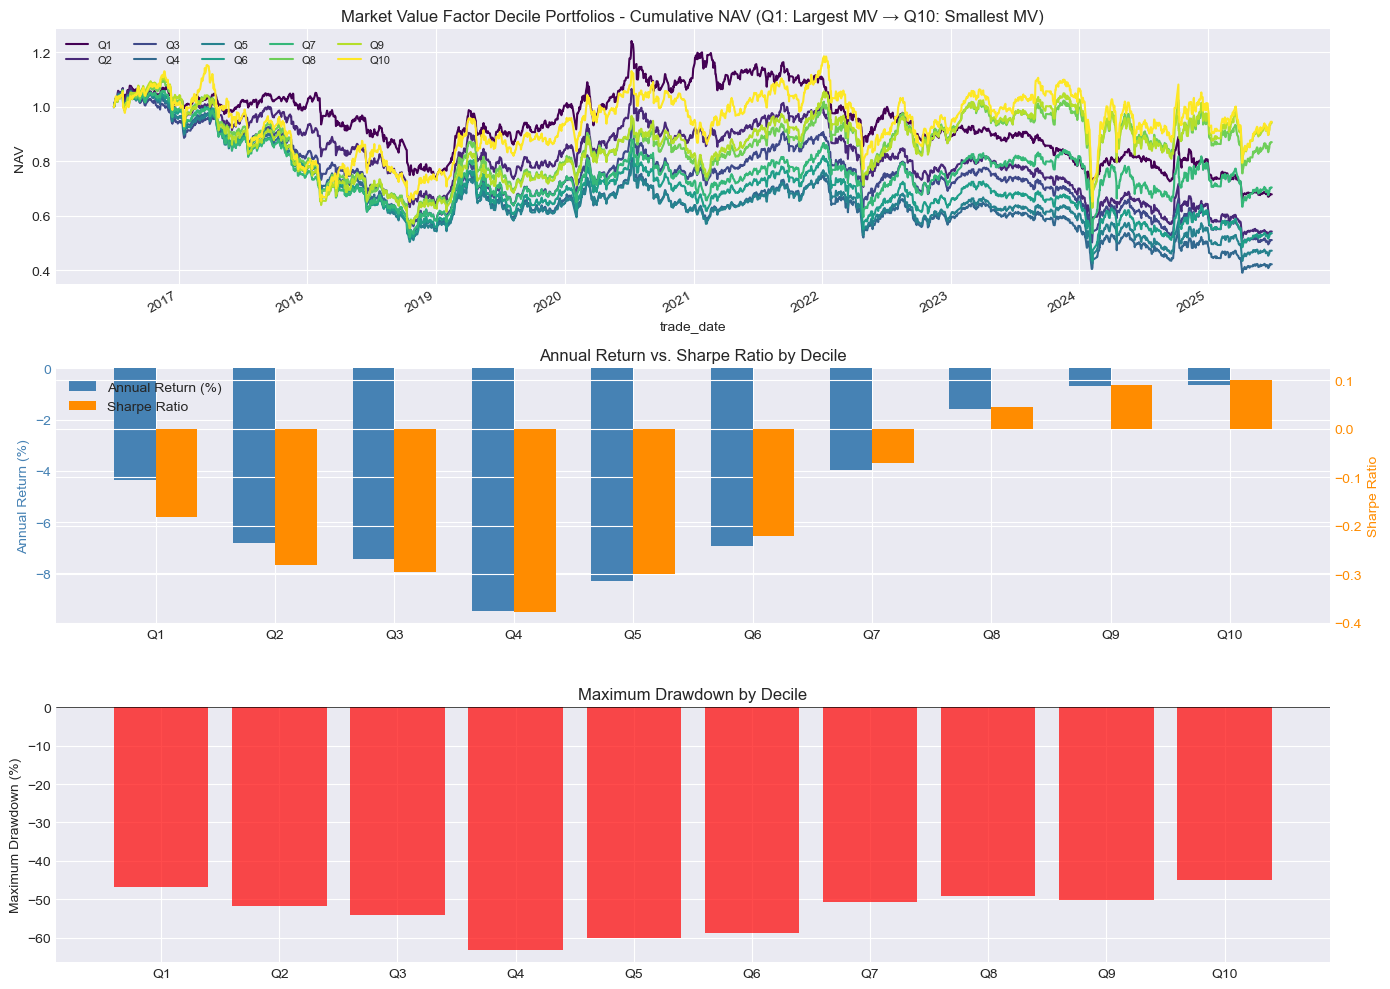


========== Performance Metrics ==========
    AnnualReturn    Sharpe MaxDrawdown
Q1     -0.043742 -0.181258   -0.468878
Q2     -0.068197 -0.280072   -0.517105
Q3     -0.074583  -0.29489   -0.540605
Q4     -0.094775 -0.376792   -0.632138
Q5     -0.083021 -0.298679   -0.600391
Q6      -0.06949 -0.220144   -0.588818
Q7      -0.03969 -0.070288   -0.507116
Q8     -0.015907  0.045793    -0.49084
Q9     -0.006942  0.091233   -0.501719
Q10    -0.006492  0.100853   -0.450319


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ===================== Configuration =====================
CONFIG = {
    "START_DATE": "2016-07-01",
    "END_DATE": "2025-06-30",
    "REBALANCE_FREQ": 5,               # Rebalance every 5 trading days
    "N_QUANTILES": 10,                 # Deciles
    "TRANSACTION_FEE": 0.001,          # Transaction fee 0.1%
    "PRICE_FILE": "data/eod_prices.parquet",
    "FACTOR_COL": "mv_flt_std",        # Market value factor column name (raw factor before winsorization)
    "USE_WINSORIZE": True,             # Whether to winsorize factor at 1%/99%
    "WINSORIZE_LIMITS": (0.01, 0.01),
}

# ===================== Helper Functions =====================
def calc_metrics(returns_series, rf=0.0, periods_per_year=252):
    """Calculate annualized return, Sharpe ratio, and maximum drawdown"""
    if len(returns_series) == 0:
        return np.nan, np.nan, np.nan
    cum_ret = (1 + returns_series).cumprod()
    total_return = cum_ret.iloc[-1] - 1
    years = len(returns_series) / periods_per_year
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    excess_returns = returns_series - rf / periods_per_year
    sharpe = np.sqrt(periods_per_year) * excess_returns.mean() / excess_returns.std() if excess_returns.std() != 0 else 0
    cummax = cum_ret.cummax()
    drawdown = (cum_ret - cummax) / cummax
    max_drawdown = drawdown.min()
    return annual_return, sharpe, max_drawdown

def quantile_backtest_mv(factor_df, price_pivot, config):
    """Market value factor decile backtest"""
    print("=" * 60)
    print("Market Value Factor Decile Portfolio Backtest (Group 1: Largest MV → Group 10: Smallest MV)")
    print(f"Rebalance frequency: every {config['REBALANCE_FREQ']} trading days")
    print(f"Transaction fee: {config['TRANSACTION_FEE']*100:.1f}%")
    print("=" * 60)

    # Prepare factor data: ensure date is datetime, filter backtest period
    factor = factor_df.copy()
    factor['trade_date'] = pd.to_datetime(factor['trade_date'])
    factor = factor[(factor['trade_date'] >= config["START_DATE"]) & 
                    (factor['trade_date'] <= config["END_DATE"])]
    # Keep only A-shares (stock code ending with .SH or .SZ)
    factor = factor[factor['stock_code'].str.endswith(('SH', 'SZ'))]

    # Price data date index
    all_dates = price_pivot.index
    all_dates = all_dates[(all_dates >= pd.Timestamp(config["START_DATE"])) & 
                          (all_dates <= pd.Timestamp(config["END_DATE"]))]
    if len(all_dates) == 0:
        raise ValueError("No valid trading days in backtest period")

    # Rebalance dates
    rebalance_dates = all_dates[::config["REBALANCE_FREQ"]].tolist()
    rebalance_dates = [d for d in rebalance_dates if d <= pd.Timestamp(config["END_DATE"])]

    # Store daily returns for each quantile group (indexed by date)
    quantile_ret_dict = {q: {} for q in range(config["N_QUANTILES"])}

    # Event-driven backtest
    for i, current_date in enumerate(tqdm(rebalance_dates, desc="Backtesting")):
        next_date = rebalance_dates[i+1] if i+1 < len(rebalance_dates) else all_dates[-1]

        # Factor data on current rebalance date
        daily_factor = factor[factor['trade_date'] == current_date].copy()
        if daily_factor.empty:
            continue

        # Optional: winsorization (consistent with original stock selection logic)
        if config["USE_WINSORIZE"]:
            from scipy.stats.mstats import winsorize
            daily_factor['factor_clean'] = winsorize(
                daily_factor[config["FACTOR_COL"]].values,
                limits=config["WINSORIZE_LIMITS"],
                inclusive=(True, True)
            )
            factor_col = 'factor_clean'
        else:
            factor_col = config["FACTOR_COL"]

        daily_factor = daily_factor.dropna(subset=[factor_col])
        if daily_factor.empty:
            continue

        # Sort by factor value and split into deciles
        daily_factor = daily_factor.sort_values(factor_col, ascending=True)  # Small MV first
        daily_factor['quantile'] = pd.qcut(daily_factor[factor_col],
                                           q=config["N_QUANTILES"],
                                           labels=False,
                                           duplicates='drop')
        groups = daily_factor.groupby('quantile')
        actual_groups = set(groups.groups.keys())

        # Trading days within current rebalance period
        period_dates = all_dates[(all_dates >= current_date) & (all_dates < next_date)]
        if len(period_dates) == 0:
            continue

        # Calculate daily returns for each quantile group
        for q in range(config["N_QUANTILES"]):
            if q in actual_groups:
                group_stocks = groups.get_group(q)
                stock_list = group_stocks['stock_code'].tolist()
                if len(stock_list) == 0:
                    daily_returns = pd.Series(0, index=period_dates)
                else:
                    # Extract prices and compute equal-weighted returns
                    price_sub = price_pivot[stock_list].reindex(period_dates)
                    price_sub = price_sub.fillna(method='ffill')
                    ret_sub = price_sub.pct_change().fillna(0)
                    daily_returns = ret_sub.mean(axis=1)
            else:
                daily_returns = pd.Series(0, index=period_dates)

            # Deduct transaction fee on the rebalance day
            if config["TRANSACTION_FEE"] > 0 and len(daily_returns) > 0:
                daily_returns.iloc[0] -= config["TRANSACTION_FEE"]

            # Store
            for date, ret in daily_returns.items():
                quantile_ret_dict[q][date] = ret

    # Build full time series (fill missing dates with 0)
    quantile_series = {}
    for q in range(config["N_QUANTILES"]):
        s = pd.Series(quantile_ret_dict[q], dtype=float)
        s = s.reindex(all_dates, fill_value=0)
        quantile_series[q] = s

    # Calculate performance metrics
    metrics_df = pd.DataFrame(index=[f"Q{i+1}" for i in range(config["N_QUANTILES"])],
                              columns=["AnnualReturn", "Sharpe", "MaxDrawdown"])
    for q in range(config["N_QUANTILES"]):
        ret_series = quantile_series[q].dropna()
        if len(ret_series) == 0:
            continue
        ann_ret, sharpe, mdd = calc_metrics(ret_series)
        metrics_df.iloc[q] = [ann_ret, sharpe, mdd]

    # Cumulative NAV
    nav_df = pd.DataFrame(index=all_dates)
    for q in range(config["N_QUANTILES"]):
        nav_df[f"Q{q+1}"] = (1 + quantile_series[q]).cumprod()

    # Plotting
    plt.style.use('seaborn-v0_8-darkgrid')
    fig = plt.figure(figsize=(14, 10))

    ax1 = plt.subplot(3, 1, 1)
    nav_df.plot(ax=ax1, colormap='viridis', lw=1.5)
    ax1.set_title('Market Value Factor Decile Portfolios - Cumulative NAV (Q1: Largest MV → Q10: Smallest MV)', fontsize=12)
    ax1.set_ylabel('NAV')
    ax1.legend(loc='upper left', ncol=5, fontsize=8)

    ax2 = plt.subplot(3, 1, 2)
    x = np.arange(len(metrics_df))
    width = 0.35
    ann_ret_vals = metrics_df['AnnualReturn'].values * 100
    sharpe_vals = metrics_df['Sharpe'].values
    bars1 = ax2.bar(x - width/2, ann_ret_vals, width, label='Annual Return (%)', color='steelblue')
    ax2.set_ylabel('Annual Return (%)', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')
    ax3 = ax2.twinx()
    bars2 = ax3.bar(x + width/2, sharpe_vals, width, label='Sharpe Ratio', color='darkorange')
    ax3.set_ylabel('Sharpe Ratio', color='darkorange')
    ax3.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"Q{i+1}" for i in range(len(metrics_df))])
    ax2.set_title('Annual Return vs. Sharpe Ratio by Decile')
    ax2.legend([bars1, bars2], ['Annual Return (%)', 'Sharpe Ratio'], loc='upper left')

    ax4 = plt.subplot(3, 1, 3)
    mdd_vals = metrics_df['MaxDrawdown'].values * 100
    colors = ['green' if x > -0.1 else 'red' for x in mdd_vals]
    ax4.bar(x, mdd_vals, color=colors, alpha=0.7)
    ax4.set_ylabel('Maximum Drawdown (%)')
    ax4.set_xticks(x)
    ax4.set_xticklabels([f"Q{i+1}" for i in range(len(metrics_df))])
    ax4.set_title('Maximum Drawdown by Decile')
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    plt.tight_layout()
    plt.savefig('mv_factor_quantile_performance.png', dpi=200)
    plt.show()

    # Output performance table
    print("\n========== Performance Metrics ==========")
    print(metrics_df.round(4))

    # Monotonicity test
    from scipy.stats import spearmanr
    rank = np.arange(1, len(metrics_df)+1)
    ann_ret = metrics_df['AnnualReturn'].values
    valid = ~np.isnan(ann_ret)
    if valid.sum() > 1:
        corr, pval = spearmanr(rank[valid], ann_ret[valid])
        print(f"\nSpearman correlation between annual return and quantile rank: {corr:.4f} (p-value: {pval:.4f})")
        if corr > 0.5 and pval < 0.05:
            print("Conclusion: Strong monotonicity, large-cap group significantly outperforms small-cap group.")
        elif corr > 0:
            print("Conclusion: Weak monotonicity.")
        else:
            print("Conclusion: No clear monotonicity or reverse monotonicity.")
    else:
        print("Insufficient valid groups for monotonicity test.")

    return nav_df, metrics_df

# ===================== Load Data and Run =====================
if __name__ == "__main__":
    # 1. Load price data (wide format)
    price = pd.read_parquet(CONFIG["PRICE_FILE"])
    price['trade_date'] = pd.to_datetime(price['trade_date'])
    # Assume price file contains trade_date, stock_code, adjusted_close
    price_pivot = price.pivot(index='trade_date', columns='stock_code', values='adjusted_close')
    price_pivot = price_pivot.sort_index()
    price_pivot.index = pd.to_datetime(price_pivot.index)

    # 2. Load market value factor data (assuming mv_factor_dt is already available)
    #    If not, read from your parquet file, e.g.:
    # mv_factor_dt = pd.read_parquet("path/to/mv_factor.parquet")
    # Note: mv_factor_dt must contain columns: trade_date, stock_code, mv_flt_std

    # Ensure factor data format is correct
    mv_factor_dt['trade_date'] = pd.to_datetime(mv_factor_dt['trade_date'].astype(str))
    mv_factor_dt = mv_factor_dt[mv_factor_dt['stock_code'].str.endswith(('SZ', 'SH'))]

    # 3. Run decile backtest
    nav_df, metrics_df = quantile_backtest_mv(mv_factor_dt, price_pivot, CONFIG)